This notebook is here as a last minute thing after the error with the jupiter notebook in visual studio that stoped working

For this I need the:
validation set /beta
the ridge regression model
the featue weigths (just in case), please make sure they are in colab folder

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score
import pickle

In [3]:

import catboost

In [4]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import matthews_corrcoef, confusion_matrix

In [6]:
catboost_model = pickle.load(open('/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/models/RNAs_z_Combat_7_SMOTE_seq_regressor_556i_10.pkl', 'rb'))

In [7]:
test_file="RNAseq_Combat_z_score_Test_set.csv"

In [8]:
test_data = pd.read_csv(test_file)
test_data.columns

Index(['ENSG00000000003.14', 'ENSG00000000005.5', 'ENSG00000000419.12',
       'ENSG00000000457.13', 'ENSG00000000460.16', 'ENSG00000000938.12',
       'ENSG00000000971.15', 'ENSG00000001036.13', 'ENSG00000001084.11',
       'ENSG00000001167.14',
       ...
       'ENSG00000285491.1', 'ENSG00000285505.1', 'ENSG00000285508.1',
       'ENSG00000285509.1', 'Age', 'Status', 'Experiment', 'Age.1', 'Sample',
       'Sex'],
      dtype='object', length=34511)

In [9]:
# prompt: remove NAN in X_test_data

import pandas as pd
import numpy as np

# ... (your existing code)

test_data = test_data.fillna(0) # Replace NaN values with 0
# or
# X_test_data = X_test_data.dropna() # Remove rows with NaN values
# or other methods to handle NaN values depending on the context

# ... (rest of your code)

In [10]:
test_data.drop(columns=["Age.1"], inplace=True)
X_test_data = test_data[test_data.columns[:-5]]
z_test_data = test_data[test_data.columns[-4:]]
y_test_data = test_data["Age"]
z_test_data = z_test_data["Experiment"]

In [11]:
# prompt: Create a dataframe that has the columns Age, Experiment and the Sample as index using test_data

# Create the DataFrame
df= pd.DataFrame({'Age': y_test_data, 'Experiment': z_test_data})
df = df.set_index(pd.Index(range(len(df)))) #Setting the sample as index

df

,Age,Experiment
0,24.0,GSE157585
1,18.0,GSE167186
2,23.0,GSE167186
3,26.4,GSE60590
4,71.0,GSE157585
...,...,...
103,71.0,GSE157585
104,23.0,GSE167186
105,72.0,GSE164471
106,71.0,GSE157585


In [12]:
X_test_data

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285458.1,ENSG00000285470.1,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1
0,-0.022233,-0.024446,-0.006216,-0.024515,-0.023171,-0.023202,-0.019452,-0.021846,-0.022867,-0.023905,...,-0.021222,-0.024522,-0.024480,-0.024511,-0.024499,-0.023623,-0.024472,-0.024526,-0.023199,-0.024432
1,-0.023307,-0.025360,-0.006206,-0.022286,-0.022653,-0.024454,-0.018532,-0.020077,-0.018804,-0.020995,...,-0.020113,-0.025321,-0.025120,-0.025282,-0.025088,-0.024710,-0.025252,-0.025311,-0.024447,-0.025087
2,-0.027950,-0.030171,-0.006227,-0.026315,-0.025683,-0.028757,-0.020073,-0.022860,-0.020748,-0.024276,...,-0.022675,-0.030003,-0.029834,-0.029983,-0.029799,-0.029041,-0.029934,-0.029985,-0.022886,-0.029776
3,-0.024681,-0.028953,-0.002464,-0.027633,-0.027815,-0.027149,-0.019945,-0.025554,-0.020408,-0.027101,...,-0.025233,-0.028767,-0.029022,-0.028779,-0.028634,-0.026764,-0.028774,-0.028772,-0.027571,-0.028812
4,-0.021846,-0.026700,0.003155,-0.022868,-0.023732,-0.026121,-0.013602,-0.018935,-0.015076,-0.019944,...,-0.020558,-0.026779,-0.026721,-0.026766,-0.026488,-0.026991,-0.026722,-0.026784,-0.025465,-0.026577
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,-0.025402,-0.027702,-0.001319,-0.025818,-0.025609,-0.027285,-0.023140,-0.022924,-0.020265,-0.024281,...,-0.023543,-0.027779,-0.027220,-0.027766,-0.026714,-0.024396,-0.027726,-0.027783,-0.026468,-0.027604
104,-0.020350,-0.026256,-0.006269,-0.023194,-0.023090,-0.025255,-0.018721,-0.020525,-0.019203,-0.021669,...,-0.020478,-0.026193,-0.025998,-0.026158,-0.025965,-0.025516,-0.026124,-0.026181,-0.018528,-0.025961
105,-0.023877,-0.028292,-0.003818,-0.026749,-0.026163,-0.027351,-0.020208,-0.023042,-0.024271,-0.025981,...,-0.020212,-0.028309,-0.028245,-0.028309,-0.028252,-0.027582,-0.028327,-0.028302,-0.027453,-0.027923
106,-0.025112,-0.029562,0.000282,-0.026724,-0.027813,-0.029708,-0.013082,-0.021109,-0.021883,-0.024146,...,-0.025092,-0.030153,-0.030124,-0.030141,-0.029958,-0.029177,-0.030107,-0.030156,-0.028848,-0.029939


In [13]:

y_pred = catboost_model.predict(X_test_data)
y_pred



array([23.13467552, 25.60350791, 24.47436229, 39.74936022, 68.61705117,
       37.0575571 , 69.31677925, 29.43772151, 30.30538996, 75.70363389,
       47.15950798, 68.20300559, 75.1430194 , 45.76108083, 74.69597391,
       68.75349299, 65.17999242, 52.98025596, 71.48840631, 28.90434047,
       24.56458571, 69.11504748, 77.22629141, 50.27325679, 33.78223595,
       70.49786633, 68.51997192, 28.36647997, 74.97193678, 28.82772205,
       29.851136  , 24.68453411, 64.34050661, 25.60646472, 68.64754806,
       47.44348279, 67.85740179, 48.39744852, 47.90117911, 26.5860913 ,
       68.74721386, 23.16648716, 68.24891781, 77.66423451, 71.7438981 ,
       31.96847584, 69.89347123, 43.84872111, 67.94672651, 51.10482178,
       76.51109771, 76.52942871, 49.9919182 , 72.89631268, 68.51568654,
       28.85414397, 68.300401  , 60.15793759, 50.50493633, 58.97071552,
       64.12107861, 63.74597495, 74.26128515, 70.28923422, 22.81329641,
       52.69647469, 23.99470041, 73.21228604, 24.31956706, 30.83

In [14]:

# Calculate evaluation metrics
mse = mean_squared_error(y_test_data, y_pred)
rmse = mean_squared_error(y_test_data, y_pred, squared=False)  # Calculate RMSE from MSE
mae = mean_absolute_error(y_test_data, y_pred)
r2 = r2_score(y_test_data, y_pred)


result_metrics = {"Method": "Catboost",  "MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}


results = pd.DataFrame({'Actual': y_test_data, 'Predicted': y_pred, 'Group': z_test_data})

In [15]:
results

,Actual,Predicted,Group
0,24.0,23.134676,GSE157585
1,18.0,25.603508,GSE167186
2,23.0,24.474362,GSE167186
3,26.4,39.749360,GSE60590
4,71.0,68.617051,GSE157585
...,...,...,...
103,71.0,70.976014,GSE157585
104,23.0,25.401901,GSE167186
105,72.0,75.074340,GSE164471
106,71.0,68.201341,GSE157585


In [16]:
pwd

'/home/karen/Documents/GitHub/Identify_muscle_age_genes/Shap_values'

In [17]:
results.to_csv("results_validationSet_actualVspredicted_catboost_10.csv")

In [18]:
from convert_ensembl_2_symbol import convert_to_symbol, filter_nameless_genes

In [19]:
from anndata import AnnData
import scanpy as sc
import pickle

# load annot
with open('annot.pkl', 'rb') as f:
    annot = pickle.load(f)


In [20]:
ensebl_names = X_test_data.columns
ensebl_names = filter_nameless_genes(ensebl_names, annot)
symbol_names = convert_to_symbol(ensebl_names, annot)

In [21]:
ensebl_names = pd.Series(ensebl_names)
symbol_names = pd.Series(symbol_names)

# Replace NaN values in symbol_names with values from ensebl_names
#symbol_names = np.where(symbol_names.isna(), ensebl_names, symbol_names)

In [22]:
symbol_names = symbol_names.fillna(ensebl_names)


In [23]:
symbol_names

0                   TSPAN6
1                     TNMD
2                     DPM1
3                    SCYL3
4                    FIRRM
               ...        
34500                H2BK1
34501              OR1Q1BP
34502    ENSG00000285505.1
34503    ENSG00000285508.1
34504          TBCEL-TECTA
Length: 34505, dtype: object

In [24]:
# prompt: take the X_test_data columns, if the value of .split(".")[0] is in ensebl_names, get the same index on ensebl_names but in symbol_names

# Assuming 'ensebl_names' and 'symbol_names' are lists of the same length
# and that the indices in the lists correspond correctly.

# Create a mapping from Ensembl IDs to gene symbols
ensembl_to_symbol = dict(zip(ensebl_names, symbol_names))

# if symbol_name is nan or variant, replace with the same ensebl_name
for key, value in ensembl_to_symbol.items():
    if pd.isna(value) or value =="nan" or value is None:
        ensembl_to_symbol[key] = key

#if X_test_data.colum is not in ensembl_to_symbol, add it with value the same as the key
for col in X_test_data.columns:
    if col not in ensembl_to_symbol:
        ensembl_to_symbol[col] = col
# Initialize an empty list to store the gene symbols for X_test_data columns
selected_symbols = []


# Iterate over columns in X_test_data
for ensembl_id in X_test_data.columns:
    if ensembl_id in ensembl_to_symbol:
        selected_symbols.append(ensembl_to_symbol[ensembl_id])
    else:
        # Handle cases where the Ensembl ID is not found in the mapping.
        # For example, append the original column name or a placeholder
        selected_symbols.append(ensembl_id) # Or selected_symbols.append("Not Found")

# Now 'selected_symbols' contains the corresponding gene symbols for the columns
# in X_test_data, or the original column name if the ensembl ID was not found.

In [25]:
selected_symbols[:10]

['TSPAN6',
 'TNMD',
 'DPM1',
 'SCYL3',
 'FIRRM',
 'FGR',
 'CFH',
 'FUCA2',
 'GCLC',
 'NFYA']

In [26]:
#
X_test_data.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285458.1,ENSG00000285470.1,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1
0,-0.022233,-0.024446,-0.006216,-0.024515,-0.023171,-0.023202,-0.019452,-0.021846,-0.022867,-0.023905,...,-0.021222,-0.024522,-0.024480,-0.024511,-0.024499,-0.023623,-0.024472,-0.024526,-0.023199,-0.024432
1,-0.023307,-0.025360,-0.006206,-0.022286,-0.022653,-0.024454,-0.018532,-0.020077,-0.018804,-0.020995,...,-0.020113,-0.025321,-0.025120,-0.025282,-0.025088,-0.024710,-0.025252,-0.025311,-0.024447,-0.025087
2,-0.027950,-0.030171,-0.006227,-0.026315,-0.025683,-0.028757,-0.020073,-0.022860,-0.020748,-0.024276,...,-0.022675,-0.030003,-0.029834,-0.029983,-0.029799,-0.029041,-0.029934,-0.029985,-0.022886,-0.029776
3,-0.024681,-0.028953,-0.002464,-0.027633,-0.027815,-0.027149,-0.019945,-0.025554,-0.020408,-0.027101,...,-0.025233,-0.028767,-0.029022,-0.028779,-0.028634,-0.026764,-0.028774,-0.028772,-0.027571,-0.028812
4,-0.021846,-0.026700,0.003155,-0.022868,-0.023732,-0.026121,-0.013602,-0.018935,-0.015076,-0.019944,...,-0.020558,-0.026779,-0.026721,-0.026766,-0.026488,-0.026991,-0.026722,-0.026784,-0.025465,-0.026577


In [27]:
X_test_data_ensembl = X_test_data.copy()
X_test_data_ensembl.columns = ensebl_names
X_test_data_ensembl.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285458.1,ENSG00000285470.1,ENSG00000285471.1,ENSG00000285472.1,NaN,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1
0,-0.022233,-0.024446,-0.006216,-0.024515,-0.023171,-0.023202,-0.019452,-0.021846,-0.022867,-0.023905,...,-0.021222,-0.024522,-0.024480,-0.024511,-0.024499,-0.023623,-0.024472,-0.024526,-0.023199,-0.024432
1,-0.023307,-0.025360,-0.006206,-0.022286,-0.022653,-0.024454,-0.018532,-0.020077,-0.018804,-0.020995,...,-0.020113,-0.025321,-0.025120,-0.025282,-0.025088,-0.024710,-0.025252,-0.025311,-0.024447,-0.025087
2,-0.027950,-0.030171,-0.006227,-0.026315,-0.025683,-0.028757,-0.020073,-0.022860,-0.020748,-0.024276,...,-0.022675,-0.030003,-0.029834,-0.029983,-0.029799,-0.029041,-0.029934,-0.029985,-0.022886,-0.029776
3,-0.024681,-0.028953,-0.002464,-0.027633,-0.027815,-0.027149,-0.019945,-0.025554,-0.020408,-0.027101,...,-0.025233,-0.028767,-0.029022,-0.028779,-0.028634,-0.026764,-0.028774,-0.028772,-0.027571,-0.028812
4,-0.021846,-0.026700,0.003155,-0.022868,-0.023732,-0.026121,-0.013602,-0.018935,-0.015076,-0.019944,...,-0.020558,-0.026779,-0.026721,-0.026766,-0.026488,-0.026991,-0.026722,-0.026784,-0.025465,-0.026577


In [28]:

# Assuming X_test_data is your feature matrix for the test set
explainer = shap.Explainer(catboost_model)
explainer.expected_value

array([5.16836462])

In [29]:
explainer.expected_value

array([5.16836462])

In [30]:
X_test_data.columns
# check for repeated columns


Index(['ENSG00000000003.14', 'ENSG00000000005.5', 'ENSG00000000419.12',
       'ENSG00000000457.13', 'ENSG00000000460.16', 'ENSG00000000938.12',
       'ENSG00000000971.15', 'ENSG00000001036.13', 'ENSG00000001084.11',
       'ENSG00000001167.14',
       ...
       'ENSG00000285458.1', 'ENSG00000285470.1', 'ENSG00000285471.1',
       'ENSG00000285472.1', 'ENSG00000285476.1', 'ENSG00000285480.1',
       'ENSG00000285491.1', 'ENSG00000285505.1', 'ENSG00000285508.1',
       'ENSG00000285509.1'],
      dtype='object', length=34505)

In [31]:
repeated_columns = X_test_data.columns[X_test_data.columns.duplicated()].unique()
repeated_columns

Index([], dtype='object')

In [32]:
for col in repeated_columns:
    col_indices = [i for i, x in enumerate(X_test_data.columns) if x == col]
    if len(col_indices) > 1:
        for idx in col_indices[1:]:
            X_test_data.columns.values[idx] = col + '*'
X_test_data.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285458.1,ENSG00000285470.1,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1
0,-0.022233,-0.024446,-0.006216,-0.024515,-0.023171,-0.023202,-0.019452,-0.021846,-0.022867,-0.023905,...,-0.021222,-0.024522,-0.024480,-0.024511,-0.024499,-0.023623,-0.024472,-0.024526,-0.023199,-0.024432
1,-0.023307,-0.025360,-0.006206,-0.022286,-0.022653,-0.024454,-0.018532,-0.020077,-0.018804,-0.020995,...,-0.020113,-0.025321,-0.025120,-0.025282,-0.025088,-0.024710,-0.025252,-0.025311,-0.024447,-0.025087
2,-0.027950,-0.030171,-0.006227,-0.026315,-0.025683,-0.028757,-0.020073,-0.022860,-0.020748,-0.024276,...,-0.022675,-0.030003,-0.029834,-0.029983,-0.029799,-0.029041,-0.029934,-0.029985,-0.022886,-0.029776
3,-0.024681,-0.028953,-0.002464,-0.027633,-0.027815,-0.027149,-0.019945,-0.025554,-0.020408,-0.027101,...,-0.025233,-0.028767,-0.029022,-0.028779,-0.028634,-0.026764,-0.028774,-0.028772,-0.027571,-0.028812
4,-0.021846,-0.026700,0.003155,-0.022868,-0.023732,-0.026121,-0.013602,-0.018935,-0.015076,-0.019944,...,-0.020558,-0.026779,-0.026721,-0.026766,-0.026488,-0.026991,-0.026722,-0.026784,-0.025465,-0.026577


In [33]:
#X_test_data['C4orf36']

In [34]:
pinx1_indices = [i for i, col in enumerate(X_test_data.columns) if col == 'PINX1']
pinx1_indices

[]

In [35]:
pinx1_columns = test_data.iloc[:, pinx1_indices]
pinx1_columns

""
0
1
2
3
4
...
103
104
105
106


In [36]:
shap_values = explainer(X_test_data, check_additivity=False)


In [37]:
shap_values.feature_names = [str(name) for name in symbol_names]
#len(symbol_names)

In [38]:
with open('shap_values_catboost_10.pkl', 'wb') as f:
    pickle.dump(shap_values, f)

In [39]:
X_test_data.columns = selected_symbols

In [40]:
# prompt: Save the SHAP value for each gene

# Assuming X_test_data is your feature matrix for the test set
# and shap_values are already calculated as in your provided code.

# Create a DataFrame to store SHAP values for each gene
shap_df = pd.DataFrame(shap_values.values, columns=X_test_data.columns)
shap_df
# Save the DataFrame to a CSV file
shap_df.to_csv("shap_values_by_gene_Catboost_10_extended.csv", index=False)

In [41]:
shap_df= pd.read_csv("shap_values_by_gene_Catboost_10_extended.csv")
shap_df

,TSPAN6,TNMD,DPM1,SCYL3,FIRRM,FGR,CFH,FUCA2,GCLC,NFYA,...,C4orf36.1,TUSC2P1,ENSG00000285471.1,OR4M2-OT1,ENSG00000285476.1,H2BK1,OR1Q1BP,ENSG00000285505.1,ENSG00000285508.1,TBCEL-TECTA
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
104,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
105,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
106,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [42]:
# remove columns with 0 values
shap_df = shap_df.loc[:, (shap_df != 0).any(axis=0)]
shap_df

,RECQL,HSPB6,ARX,SKAP2,GGCT,PAFAH1B1,BLTP2,UQCRC1,CEP68,SAMD4A,...,URGCP-MRPS24,NUDT4P2,ENSG00000271250.1,ENSG00000272346.2,ENSG00000274691.1,ENSG00000275012.1,ENSG00000277998.1,ENSG00000281228.1,TBCE,ENSG00000285043.1
0,-0.004219,-0.286173,-0.027392,0.000473,0.003544,-0.000054,0.002264,-0.069413,0.002750,-0.004620,...,-0.000292,-0.037870,-0.006986,-0.000326,-0.010625,-0.000377,-0.005219,-0.000457,-0.006887,-1.148304
1,-0.004219,-0.262473,-0.027392,0.000473,0.006197,0.000167,0.004911,-0.062329,0.003251,-0.004620,...,-0.000219,-0.034925,-0.006986,-0.000326,-0.010625,-0.000377,0.004015,-0.000457,-0.006887,-1.126170
2,-0.003884,-0.282695,-0.027392,0.000473,0.004083,-0.000054,0.004911,-0.069413,0.004424,-0.004620,...,-0.000292,0.008641,-0.006986,-0.000326,-0.010625,-0.000377,0.004015,-0.000457,-0.006887,-1.148304
3,0.000247,-0.282652,-0.027392,0.000473,0.017803,0.001187,0.001233,0.023291,0.003923,-0.005070,...,0.003990,0.008465,-0.006986,-0.000326,-0.011711,-0.000377,0.004858,-0.000457,-0.012580,-1.405442
4,0.007048,0.101417,-0.018313,0.001270,0.038813,0.001187,-0.026236,0.019526,0.012373,0.015608,...,0.006667,0.008399,-0.011789,0.000323,-0.011711,0.000253,-0.006315,0.000618,-0.024085,0.847723
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,0.007048,0.116490,-0.018313,0.001270,0.044161,0.001343,0.009249,0.021513,0.011522,-0.005070,...,0.006667,0.011127,0.009617,0.000323,-0.011711,0.000253,-0.006315,0.000618,-0.024085,0.966140
104,0.264098,-0.288946,-0.027392,0.000473,0.006534,0.000167,0.004911,-0.046718,0.004424,-0.002397,...,-0.000292,0.008641,-0.006986,-0.000326,-0.010625,-0.000377,0.004015,-0.000457,0.011443,-1.148304
105,0.007048,0.142458,-0.018313,0.000604,0.045579,0.001187,0.007309,0.034721,0.005989,0.015608,...,0.006667,0.017568,-0.011789,0.000323,0.010194,0.000253,0.004858,0.000618,-0.012305,0.907907
106,0.007048,0.096240,-0.018313,0.001270,0.042899,-0.026549,-0.006742,0.021513,0.011522,-0.005070,...,0.006667,0.008399,0.009617,0.000323,-0.003872,0.000253,-0.006315,0.000618,-0.024085,1.028444


In [43]:
# for each row in shap_df, get the top 50 genes with the highest absolute shap value
# and save them in a new dataframe
top_genes={}
for index, row in shap_df.iterrows():
    top_50_genes = row.abs().nlargest(15)
    # save the origial shapvalue non abs
    genes = top_50_genes.index
    origial_shapvalue = row[genes]
    top_genes[index] = origial_shapvalue.to_dict()


In [44]:
# convert top_genes to sets
top_genes_set = {}
for key, value in top_genes.items():
    top_genes_set[key] = set(value.keys())
# find intersection of top genes_set
intersection = top_genes_set[0]
for key, value in top_genes_set.items():
    intersection = intersection.intersection(value)
intersection

{'BLCAP',
 'ENSG00000234441.1',
 'ENSG00000262855.1',
 'H3-3B',
 'NT5C2',
 'SLC16A3'}

In [45]:
# get average shap_df by column
shap_df_mean = shap_df.mean().sort_values(ascending=False)

# remove the shap_df_mean values that are between -0.001 and 0.001
len(shap_df_mean[(shap_df_mean < -0.001) | (shap_df_mean > 0.001)])


216

In [46]:
shap_df_mean

ENSG00000262855.1    0.510600
NT5C2                0.383328
SLC16A3              0.363047
ENSG00000234441.1    0.251738
UBFD1                0.219539
                       ...   
RNA5SP237           -0.020708
HSPH1               -0.021395
UBE2H               -0.051157
RNA5SP460           -0.058349
PTP4A3              -0.105652
Length: 369, dtype: float64

In [47]:
shap_df_mean.to_csv("average_shap_value_by_gene_Catboost_10_extended_2.csv")

In [48]:
results.head(10)

,Actual,Predicted,Group
0,24.0,23.134676,GSE157585
1,18.0,25.603508,GSE167186
2,23.0,24.474362,GSE167186
3,26.4,39.749360,GSE60590
4,71.0,68.617051,GSE157585
5,26.4,37.057557,GSE60590
6,71.0,69.316779,GSE157585
7,27.5,29.437722,GSE60590
8,31.0,30.305390,GSE164471
9,92.0,75.703634,GSE167186


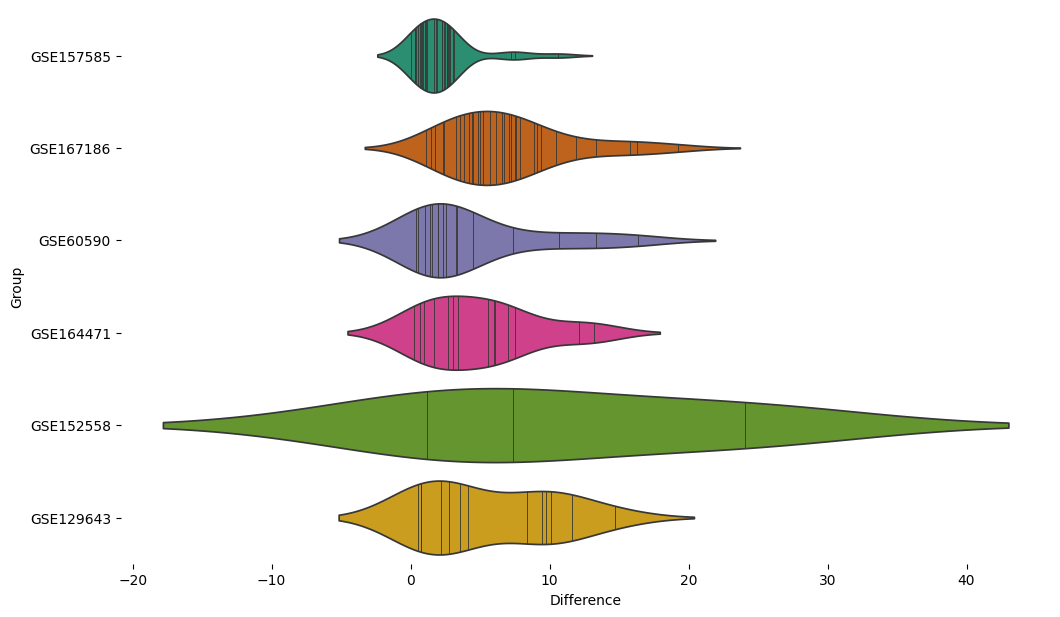

In [49]:
# @title Group vs Difference

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(results['Group'].unique()))
plt.figure(figsize=figsize)
results['Difference'] = abs(results['Predicted'] - results['Actual'])
sns.violinplot(results, x='Difference', y='Group', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)
plt.savefig("Group_vs_Difference_Catboost_10_extended.svg", bbox_inches='tight')

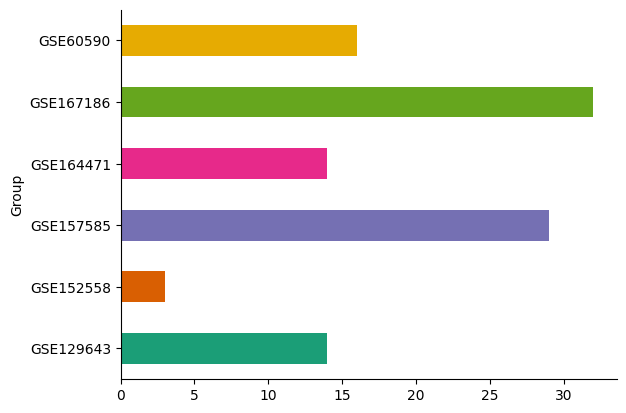

In [50]:
# @title Group

from matplotlib import pyplot as plt
import seaborn as sns
results.groupby('Group').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.savefig("Group_Catboost_10_extended.svg", bbox_inches='tight')

In [51]:
# prompt: Using dataframe results: calculate per group, what is the average absolute difference between predicted and Actual

# Calculate the absolute difference between predicted and actual values
results['Difference'] = abs(results['Predicted'] - results['Actual'])

# Group by 'Group' and calculate the average absolute difference
average_difference_by_group = results.groupby('Group')['Difference'].mean()

# Display the result
average_difference_by_group


Group
GSE129643     5.674266
GSE152558    10.862080
GSE157585     2.341388
GSE164471     5.010162
GSE167186     7.022827
GSE60590      4.536483
Name: Difference, dtype: float64

In [52]:
results[results["Group"]=="GSE152558"]

,Actual,Predicted,Group,Difference
10,46.0,47.159508,GSE152558,1.159508
37,41.0,48.397449,GSE152558,7.397449
59,83.0,58.970716,GSE152558,24.029284


Sample 0/ 108 
 Age: 24.0 
 Experiment: GSE157585 
 Predicted: Actual             24.0
Predicted     23.134676
Group         GSE157585
Difference     0.865324
Name: 0, dtype: object


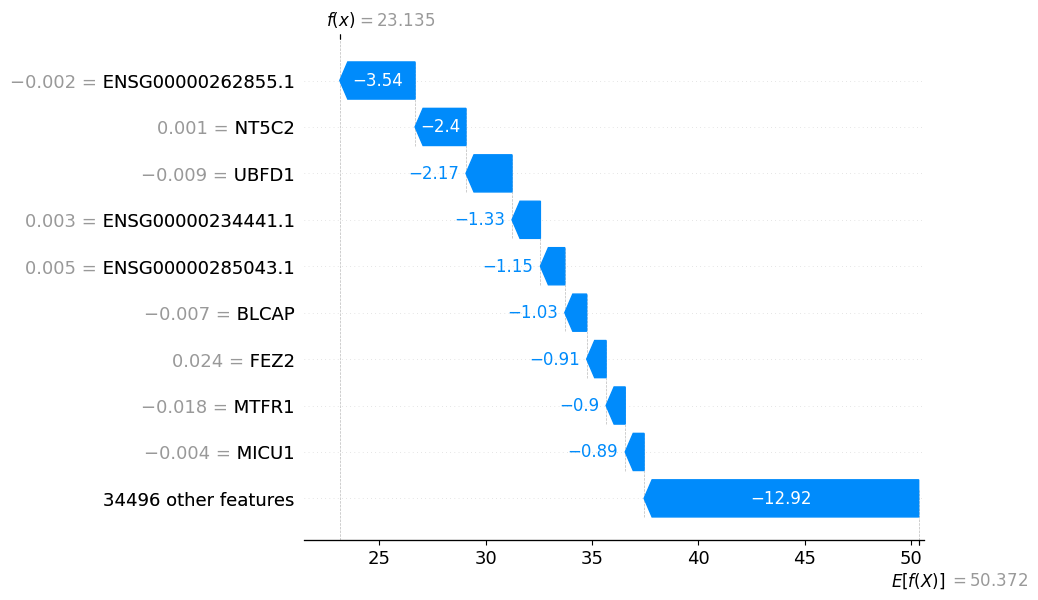

<Figure size 640x480 with 0 Axes>

In [53]:
index=0
title = f"Sample {index}/ {len(shap_values)} \n Age: {y_test_data[index]} \n Experiment: {z_test_data[index]} \n Predicted: {results.iloc[index]}"

print(title)
shap.plots.waterfall(shap_values[index])
plt.savefig(f"waterfall_plot_sample_{index}_Catboost_10_extended.svg", bbox_inches='tight')


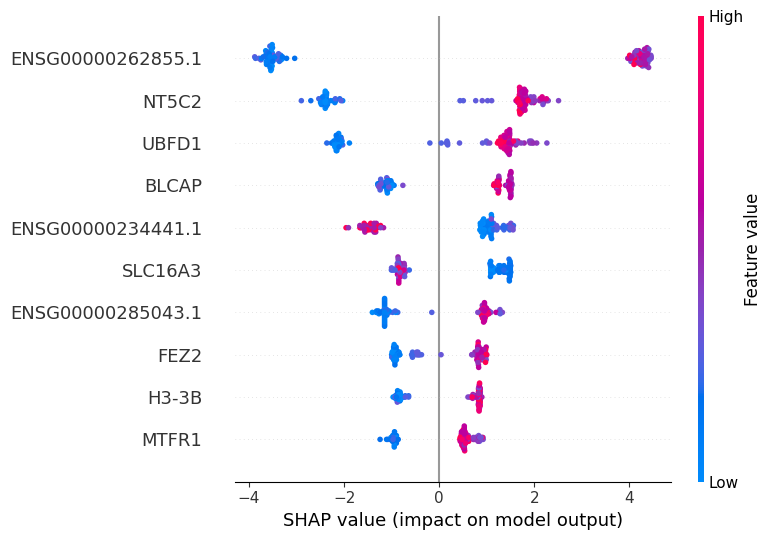

<Figure size 640x480 with 0 Axes>

In [54]:
# prompt: Run the shap.summary_plot

plot_shap =shap.summary_plot(shap_values, X_test_data, max_display=10)
plt.savefig("shap_summary_plot_Catboost_10_extended.svg", bbox_inches='tight')

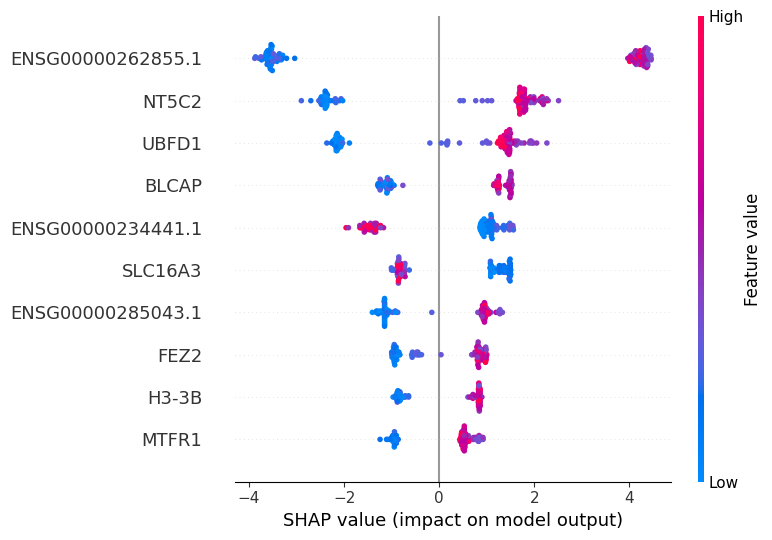

In [55]:
# prompt: save the shap figure

import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_test_data, max_display=10, show=False)
plt.savefig('summary_plot_catboost_10.png', bbox_inches='tight')

In [56]:
import sys
sys.path.append('/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning')
import getting_threshold_genes as gtg

shap_avg_values = pd.DataFrame({
    'Feature': X_test_data.columns,
    'Average SHAP Value': np.mean(shap_values.values, axis=0)
})
shap_avg_values["abs_coef"] = shap_avg_values["Average SHAP Value"].abs()


elbow_point = gtg.get_elbow_point_from_gene_rank(shap_avg_values)
threshold_genes = shap_avg_values[shap_avg_values["abs_coef"] > elbow_point]
threshold_genes.sort_values(by="abs_coef", ascending=False, inplace=True)
threshold_genes.to_csv("threshold_genes_CATBOOST_10_extended.csv", index=False)
len(threshold_genes)

97

In [58]:
threshold_genes[:20]

,Feature,Average SHAP Value,abs_coef
31022,ENSG00000262855.1,0.510600,0.510600
1318,NT5C2,0.383328,0.383328
7813,SLC16A3,0.363047,0.363047
24116,ENSG00000234441.1,0.251738,0.251738
2709,UBFD1,0.219539,0.219539
6339,H3-3B,0.191586,0.191586
960,MTFR1,0.143632,0.143632
11392,BLCAP,0.134886,0.134886
12381,FEZ2,0.130461,0.130461
14874,PTP4A3,-0.105652,0.105652
